# OPERAnet Dataset Introduction and Preprocessing (WiFi CSI and UWB)

Bocus M J, Li W, Vishwakarma S, et al. OPERAnet, a multimodal activity recognition dataset acquired from radio frequency and vision-based sensors[J]. Scientific data, 2022, 9(1): 474.

## Introduction

This multi-modality dataset evaluates passive Human Activity Recognition (HAR) and localization, including RF data such as CSI from a WiFi NIC, PWR from an SDR platform, and UWB signals from commercial hardware. Additionally, it includes vision/infrared data from Kinect sensors. 
The dataset contains approximately 8 hours of annotated measurements from six participants performing six daily activities, with over 1 million annotated data points.
More details can be found in the paper.

Download the dataset from the official website: [OPERAnet](https://figshare.com/collections/A_Comprehensive_Multimodal_Activity_Recognition_Dataset_Acquired_from_Radio_Frequency_and_Vision-Based_Sensors/5551209)

This notebook demonstrates how to preprocess the WiFi CSI and UWB data for activity recognition tasks.


### General Information

Tasks:
- Activity Recognition
- Crowd Counting
- Device-Free Localization
- Device-to-Device Localization

- The monitoring devices were installed on the extremity (boundary) of the rooms such that enclosed spaces of dimensions 2.46 m×4.40 m and 4.06 m×4.53 m were used as monitoring areas for **Room 1 and 2**, respectively. <font color='red'>exp001–exp054 were performed in Room 1 while exp055–exp061 were carried out in Room 2.</font>
- exp028 is **the crowd counting** experiment whereby six people walked randomly and continuously within the monitoring area of Room 1. Then, after approximately every 5 minutes, one person moved out of the room.
- The experiments exp034–exp048 (exp034 is the empty room background data) were device-free localization experiments involving a human target who was standing still at several positions or walking along a straight short path in a number of directions as shown in Fig. 3. The target wore a tag to get his/her ground truth position. Note that only the WiFi CSI transmitter (NUC3) and receiver (NUC2) were used (wificsi2) during these experiments for recording data and they were placed side by side.

| Experiment no.                                 | Details                                                                                                                                                                                                                       |
|------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| exp001, exp019, exp034, exp055                 | Background (1) data (empty room).                                                                                                                                                                                             |
| exp002, exp006, exp010, exp014, exp020, exp024 | Person walking (2).                                                                                                                                                                                                           |
| exp003, exp007, exp011, exp015, exp021, exp025 | Person sitting (3) and standing from chair (4).                                                                                                                                                                               |
| exp004, exp008, exp012, exp016, exp022, exp026 | Person lying down on floor (5) and standing up from floor (6).                                                                                                                                                                |
| exp005, exp009, exp013, exp017, exp023, exp027 | Person rotating upper-half of his/her body (7).                                                                                                                                                                               |
| exp018, exp029-exp033                          | Person performing the six activities (2–7) continuously and randomly (no predefined order).                                                                                                                                   |
| exp056-exp061                                  | Person performing the six activities (2–7) in a predefined order, starting with activity “walking” and ending with activity “body rotating”.                                                                                  |
| exp028                                         | Crowd counting. A maximum of six people walking continuously and randomly. Experiment starts with six people and then after every 5 minutes, one person steps out of the monitoring area.                                     |
| exp035-exp043                                  | Device-free static localization. CSI transmitter (NUC3) and CSI receiver (NUC2) are placed side by side and the target stand still at a given position for each experiment number.                                            |
| exp044-exp048                                  | Device-free dynamic localization. CSI transmitter (NUC3) and CSI receiver (NUC2) are placed side by side and the target moves along a short straight path for each experiment number.                                         |
| exp049-exp054                                  | Device-to-device localization. No human target present. CSI transmitter (NUC3) and CSI receiver (NUC2) are placed at different angles with respect to each other (−30°, 0°, +30°, −60°, 0°, +60°) for each experiment number. |

### WiFi CSI Data

| Parameter                   | Value                         |
|-----------------------------|-------------------------------|
| WiFi band                   | 5 GHz (channel 149)           |
| NIC                         | Intel 5300                    |
| Subcarriers, \( N_{sc} \)   | 30                            |
| Antenna                     | omni-directional (6 dBi)      |
| Packet rate                 | 1600 Hz                       |
| No. of transmit antennas, \( n_t \) | 3                    |
| No. of receive antennas, \( n_r \)  | 3                    |


### UWB Data (*maximum receiver bandwidth is approximately 900 MHz)

| UWB parameter                    | Ground truth system (red) | System 1 (yellow) | System 2 (blue) |
|----------------------------------|---------------------------|-------------------|-----------------|
| Channel number                   | 5                         | 4                 | 3               |
| Carrier frequency                | 6489.6 MHz                | 3993.6 MHz        | 4492.8 MHz      |
| Bandwidth                        | 499.2 MHz                 | 1331.2* MHz       | 499.2 MHz       |
| Pulse repetition frequency       | 64 MHz                    | 64 MHz            | 64 MHz          |
| Data rate                        | 6.8 Mbps                  | 6.8 Mbps          | 6.8 Mbps        |
| Preamble length                  | 128 symbols               | 128 symbols       | 128 symbols     |
| Preamble acquisition chunk size  | 8                         | 8                 | 8               |
| Preamble code                    | 9                         | 17                | 9               |


#### UWB Devices Summary

##### General Overview
- **Three UWB systems** were used during the experiments.
- The first system was used to obtain the ground truth position of the target.
- Two passive UWB systems (yellow and blue nodes) were in a multi-static configuration, exchanging CIR data among themselves.

##### System 1 (Yellow Nodes)
- Implemented using four Decawave's EVK1000 modules.
- Nodes were programmed with custom firmware for recording CIR data on all nodes.
- Node '0' acted as an initiator, exchanging Single-Sided Two-Way Ranging (SS-TWR) messages with the other three nodes.
- All nodes acted as transmitters and receivers, creating 12 communication links.
- Nodes connected to laptops via serial terminals for data recording.
- Average packet rate: around 400 Hz.

##### System 2 (Blue Nodes)
- Implemented using five Decawave's MDEK1001 modules.
- Nodes also flashed with custom firmware for CIR data recording.
- Node '0' acted as an initiator, transmitting a packet every 10 ms.
- Transmission was performed in a round-robin fashion to avoid collision.
- Nodes with IDs 1–4 connected to laptops for data recording.
- Average packet rate: around 195 Hz.

##### CIR Data Collection
- **Sampling Interval (Δτ)**: Approx. 1.0016 ns (half period of 499.2 MHz frequency).
- **PRF**: 16 MHz and 64 MHz.
- **Samples**: 992 and 1016 samples for nominal PRF.
- **CIR Data**: 
  - 35 CIR samples (system 1)
  - 50 CIR samples (system 2)
  - Correspond to sensing ranges of 10.5 m (system 1) and 15 m (system 2).
- **Normalization**: Magnitude values normalized using the Preamble Accumulation Count (PAC) value from the `RXPACC` register in the DW1000 chipset.


## Preprocessing

### Unzip the down loaded dataset

```shell
.
├── codes.zip
├── uwb1.zip
├── uwb2.zip
├── wificsi1.zip
└── wificsi2.zip
```

In [ ]:
# # import os
# # list all the directories in the current directory
# for dirpath, dirnames, filenames in os.walk('.'):
#     print(f'Found directory: {dirpath}')
#     for file_name in filenames: 
#         print(f'\t{file_name}')
#     print()

In [3]:
# # unzip the uwb1.zip file and save it to the uw1 directory
# import zipfile
# with zipfile.ZipFile('uwb1.zip', 'r') as zip_ref:
#     zip_ref.extractall('uwb1')

# # unzip the uwb2.zip file and save it to the uw2 directory
# with zipfile.ZipFile('uwb2.zip', 'r') as zip_ref:
#     zip_ref.extractall('uwb2')
    
# # unzip the wificsi1.zip file and save it to the wificsi1 directory
# with zipfile.ZipFile('wificsi1.zip', 'r') as zip_ref:
#     zip_ref.extractall('wificsi1')
    
# # unzip the wificsi2.zip file and save it to the wificsi2 directory
# with zipfile.ZipFile('wificsi2.zip', 'r') as zip_ref:
#     zip_ref.extractall('wificsi2')
    
# # unzip the codes.zip file and save it to the codes directory
# with zipfile.ZipFile('codes.zip', 'r') as zip_ref:
#     zip_ref.extractall('codes')
    

 - codes are matlab scripts on data loading, processing, and visualization, that are provided in the official website.
 - after unzipping, we will delete the zip files to save space.

 ```shell
 .
├── codes
├── uwb1
├── uwb2
├── wificsi1
└── wificsi2
```

### Processing the UWB data

In [1]:
# The following information is from the OPERAnet dataset paper.

task_experiment_index_map  = {
    'Background': [1,19,55],                     # [1,19] room 1, [55] room 2
    'sitting': [3,7,11,15,21,25],                # Room 1
    'standing_from_chair': [3,7,11,15,21,25],    # Room 1
    'lying': [4,8,12,16,22,26],                  # Room 1
    'standing_from_floor': [4,8,12,16,22,26],    # Room 1
    'body_rotating': [5,9,13,17,23,27],          # Room 1
    'random_motion': [18,29,33],                 # Room 1
    'orderly_motion': [56,57,58,59,60,61],       # Room 2
    'crowd_counting':[28],                       # Room 1;;  exp028 is **the crowd counting** experiment whereby six people walked randomly 
                                                            # and continuously within the monitoring area of Room 1.
                                                            # Then, after approximately every 5 minutes, one person moved out of the room.
}


##### Extracting the meta information

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
uwb1 = pd.read_csv('uwb1/uwb1_exp028.csv')
print(type(uwb1))
print(uwb1.head())

<class 'pandas.core.frame.DataFrame'>
      timestamp    activity   exp_no       person_id  room_no  tag4422_x  \
0  14:49:13.218  noactivity  exp_028  All Six People        1     2.8400   
1  14:49:13.233  noactivity  exp_028  All Six People        1     2.8371   
2  14:49:13.247  noactivity  exp_028  All Six People        1     2.8367   
3  14:49:13.249  noactivity  exp_028  All Six People        1     2.8367   
4  14:49:13.249  noactivity  exp_028  All Six People        1     2.8367   

   tag4422_y  tag89b3_x  tag89b3_y  tag122c_x  ...            cir26  \
0     6.6200       4.17       4.61    0.20985  ...   4.3109+6.8824i   
1     6.6207       4.17       4.61    0.21000  ...  0.94017+5.1197i   
2     6.6208       4.17       4.61    0.20987  ...  -2.0684+6.1282i   
3     6.6208       4.17       4.61    0.20987  ...   2.4286-1.2101i   
4     6.6208       4.17       4.61    0.20987  ...   5.6016+6.0081i   

                cir27               cir28            cir29            cir30  \

In [5]:
# uwb1_exp_meta_info = {
#     'task_name': [],
#     'experiment_index': [],
#     'data_shape': [],
#     'room_no_list': [],
#     'person_id_list': [],
#     'activity_list': [],
# }


# for task in task_experiment_index_map.keys():
#     for experiment_index in task_experiment_index_map[task]:
#         uwb_sys1_file = 'uwb1/' + 'uwb1_exp%03d.csv'%(experiment_index)
#         uwb_sys1_df = pd.read_csv(uwb_sys1_file)
        
#         uwb1_exp_meta_info['task_name'].append(task)
#         uwb1_exp_meta_info['experiment_index'].append(experiment_index)
#         uwb1_exp_meta_info['data_shape'].append(uwb_sys1_df.shape)
#         uwb1_exp_meta_info['room_no_list'].append(uwb_sys1_df['room_no'].unique())
#         uwb1_exp_meta_info['person_id_list'].append(uwb_sys1_df['person_id'].unique())
#         uwb1_exp_meta_info['activity_list'].append(uwb_sys1_df['activity'].unique())
    
# uwb1_exp_meta_info_df = pd.DataFrame(uwb1_exp_meta_info)
# print(uwb1_exp_meta_info_df)

# # save the meta information to a csv file
# uwb1_exp_meta_info_df.to_csv('uwb1_exp_meta_info.csv', index=False)

              task_name  experiment_index    data_shape room_no_list  \
0            Background                 1  (157791, 57)          [1]   
1            Background                19  (147938, 57)          [1]   
2            Background                55  (189885, 57)          [2]   
3               sitting                 3  (160631, 64)          [1]   
4               sitting                 7  (143202, 64)          [1]   
5               sitting                11  (151834, 64)          [1]   
6               sitting                15  (142023, 64)          [1]   
7               sitting                21  (181214, 64)          [1]   
8               sitting                25  (179547, 64)          [1]   
9   standing_from_chair                 3  (160631, 64)          [1]   
10  standing_from_chair                 7  (143202, 64)          [1]   
11  standing_from_chair                11  (151834, 64)          [1]   
12  standing_from_chair                15  (142023, 64)         

In [4]:
# uwb2_exp_meta_info = {
#     'task_name': [],
#     'experiment_index': [],
#     'data_shape': [],
#     'room_no_list': [],
#     'person_id_list': [],
#     'activity_list': [],
# }


# for task in task_experiment_index_map.keys():
#     for experiment_index in task_experiment_index_map[task]:
#         uwb_sys2_file = 'uwb2/' + 'uwb2_exp%03d.csv'%(experiment_index)
#         uwb_sys2_df = pd.read_csv(uwb_sys2_file)
        
#         uwb2_exp_meta_info['task_name'].append(task)
#         uwb2_exp_meta_info['experiment_index'].append(experiment_index)
#         uwb2_exp_meta_info['data_shape'].append(uwb_sys2_df.shape)
#         uwb2_exp_meta_info['room_no_list'].append(uwb_sys2_df['room_no'].unique())
#         uwb2_exp_meta_info['person_id_list'].append(uwb_sys2_df['person_id'].unique())
#         uwb2_exp_meta_info['activity_list'].append(uwb_sys2_df['activity'].unique())
    
# uwb2_exp_meta_info_df = pd.DataFrame(uwb2_exp_meta_info)
# print(uwb2_exp_meta_info_df)

# # save the meta information to a csv file
# uwb2_exp_meta_info_df.to_csv('uwb2_exp_meta_info.csv', index=False)

              task_name  experiment_index    data_shape room_no_list  \
0            Background                 1   (66557, 72)          [1]   
1            Background                19   (25814, 72)          [1]   
2            Background                55  (107214, 72)          [2]   
3               sitting                 3   (88638, 79)          [1]   
4               sitting                 7   (78704, 79)          [1]   
5               sitting                11   (66967, 79)          [1]   
6               sitting                15   (87734, 79)          [1]   
7               sitting                21   (81207, 79)          [1]   
8               sitting                25   (75491, 79)          [1]   
9   standing_from_chair                 3   (88638, 79)          [1]   
10  standing_from_chair                 7   (78704, 79)          [1]   
11  standing_from_chair                11   (66967, 79)          [1]   
12  standing_from_chair                15   (87734, 79)         

##### UWB activity recognition data

Based on the extracted meta information, we have the following information:

In [ ]:
# !!!!! For the activity recognition experiments (except the crowd counting experiment):

person_ids = ['One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven']
room_nos = [1,2]
activities = [
    'Background',        # no user
    'noactivity',        # static user
    'sit',
    'stand',
    'liedown',
    'standfromlie',
    'bodyrotate', 
    'random_motion',
    'orderly_motion', 
    'crowd_counting'
    ]

act_recognition_exp_indexes = [1,19,55, 3,7,11,15,21,25, 4,8,12,16,22,26, 5,9,13,17,23,27, 18,29,33, 56,57,58,59,60,61]

# task_experiment_index_map  = {
#     'Background': [1,19,55],                     # [1,19] room 1, [55] room 2
#     'sitting': [3,7,11,15,21,25],                # Room 1
#     'standing_from_chair': [3,7,11,15,21,25],    # Room 1
#     'lying': [4,8,12,16,22,26],                  # Room 1
#     'standing_from_floor': [4,8,12,16,22,26],    # Room 1
#     'body_rotating': [5,9,13,17,23,27],          # Room 1
#     'random_motion': [18,29,33],                 # Room 1
#     'orderly_motion': [56,57,58,59,60,61],       # Room 2
#     'crowd_counting':[28],                       # Room 1;;  exp028 is **the crowd counting** experiment whereby six people walked randomly 
#                                                             # and continuously within the monitoring area of Room 1.
#                                                             # Then, after approximately every 5 minutes, one person moved out of the room.
# }

###### UW1: Data segmentation and creat the database for activity recognition.

In [1]:
# from tqdm import tqdm
# import pandas as pd
# import numpy as np  
# import pickle

# OPERAnet_UWB1_Activity_Recognition_Database = {
#     'exp_id': [],
#     'person_id': [],
#     'room_no': [],
#     'activity': [],
#     'act_start_index': [],
#     'act_end_index': [],
#     'act_start_timestamp': [],
#     'act_end_timestamp': [],
#     'fp_pow_dbm': [],
#     'fp_index': [],
#     'CIR': [],
# }

# act_recognition_exp_indexes = [3,7, 11,15,21,25, 4,8,12,16,22,26, 5,9,13,17,23,27, 18,29,33, 56,57,58,59,60,61] 

# for exp_id in act_recognition_exp_indexes:
#     uwb_sys1_file = 'uwb1/' + 'uwb1_exp%03d.csv'%(exp_id)
#     uwb_sys1_df = pd.read_csv(uwb_sys1_file)
#     uwb_sys1_df['timestamp'] = pd.to_datetime(uwb_sys1_df['timestamp'], format='%H:%M:%S.%f')
#     tx_id_uwb1 = uwb_sys1_df['tx_id']
#     rx_id_uwb1 = uwb_sys1_df['rx_id']
#     # find bidirectional data between nodes 0 and 3 (UWB1)
#     idx_1 = uwb_sys1_df[(tx_id_uwb1 == 0) & (rx_id_uwb1 == 3) | (tx_id_uwb1 == 3) & (rx_id_uwb1 == 0)].index
#     Filtered_data = uwb_sys1_df.loc[idx_1]
#     # print(Filtered_data.head())
#     # convert the CIR string to complex number
#     Filtered_data.iloc[:, 29:64] = Filtered_data.iloc[:, 29:64].applymap(lambda x: complex(x.replace('i', 'j')))
    
#     for i in tqdm(range(Filtered_data.shape[0])):
#         if i == 0:
#             start_time = Filtered_data['timestamp'].iloc[0]
#             start_index = 0
#             continue
#         if Filtered_data['activity'].iloc[i] != Filtered_data['activity'].iloc[i-1]:
#             # save the previous activity information
#             OPERAnet_UWB1_Activity_Recognition_Database['exp_id'].append(exp_id)
#             OPERAnet_UWB1_Activity_Recognition_Database['person_id'].append(uwb_sys1_df['person_id'][i-1])
#             OPERAnet_UWB1_Activity_Recognition_Database['room_no'].append(uwb_sys1_df['room_no'][i-1])
#             OPERAnet_UWB1_Activity_Recognition_Database['activity'].append(uwb_sys1_df['activity'][i-1])
#             OPERAnet_UWB1_Activity_Recognition_Database['act_start_index'].append(start_index)
#             OPERAnet_UWB1_Activity_Recognition_Database['act_end_index'].append(i)
#             OPERAnet_UWB1_Activity_Recognition_Database['act_start_timestamp'].append(start_time)
#             OPERAnet_UWB1_Activity_Recognition_Database['act_end_timestamp'].append(uwb_sys1_df['timestamp'][i-1])
#             OPERAnet_UWB1_Activity_Recognition_Database['fp_pow_dbm'].append(np.array(Filtered_data['fp_pow_dbm'][start_index:i].values))
#             OPERAnet_UWB1_Activity_Recognition_Database['fp_index'].append(np.array(Filtered_data['fp_index'][start_index:i].values))
#             OPERAnet_UWB1_Activity_Recognition_Database['CIR'].append(np.array(Filtered_data.iloc[start_index:i, 29:64].values))
#             start_time = uwb_sys1_df['timestamp'][i]
#             start_index = i
            
# print("The total number of activity recognition experiments: ", len(OPERAnet_UWB1_Activity_Recognition_Database['exp_id']))

# with open('OPERAnet_UWB1_Activity_Recognition_Database.pkl', 'wb') as f:
#     pickle.dump(OPERAnet_UWB1_Activity_Recognition_Database, f)

100%|██████████| 15992/15992 [00:00<00:00, 74169.06it/s]


The total number of activity recognition experiments:  2513


dict_keys(['exp_id', 'person_id', 'room_no', 'activity', 'act_start_index', 'act_end_index', 'act_start_timestamp', 'act_end_timestamp', 'fp_pow_dbm', 'fp_index', 'CIR'])


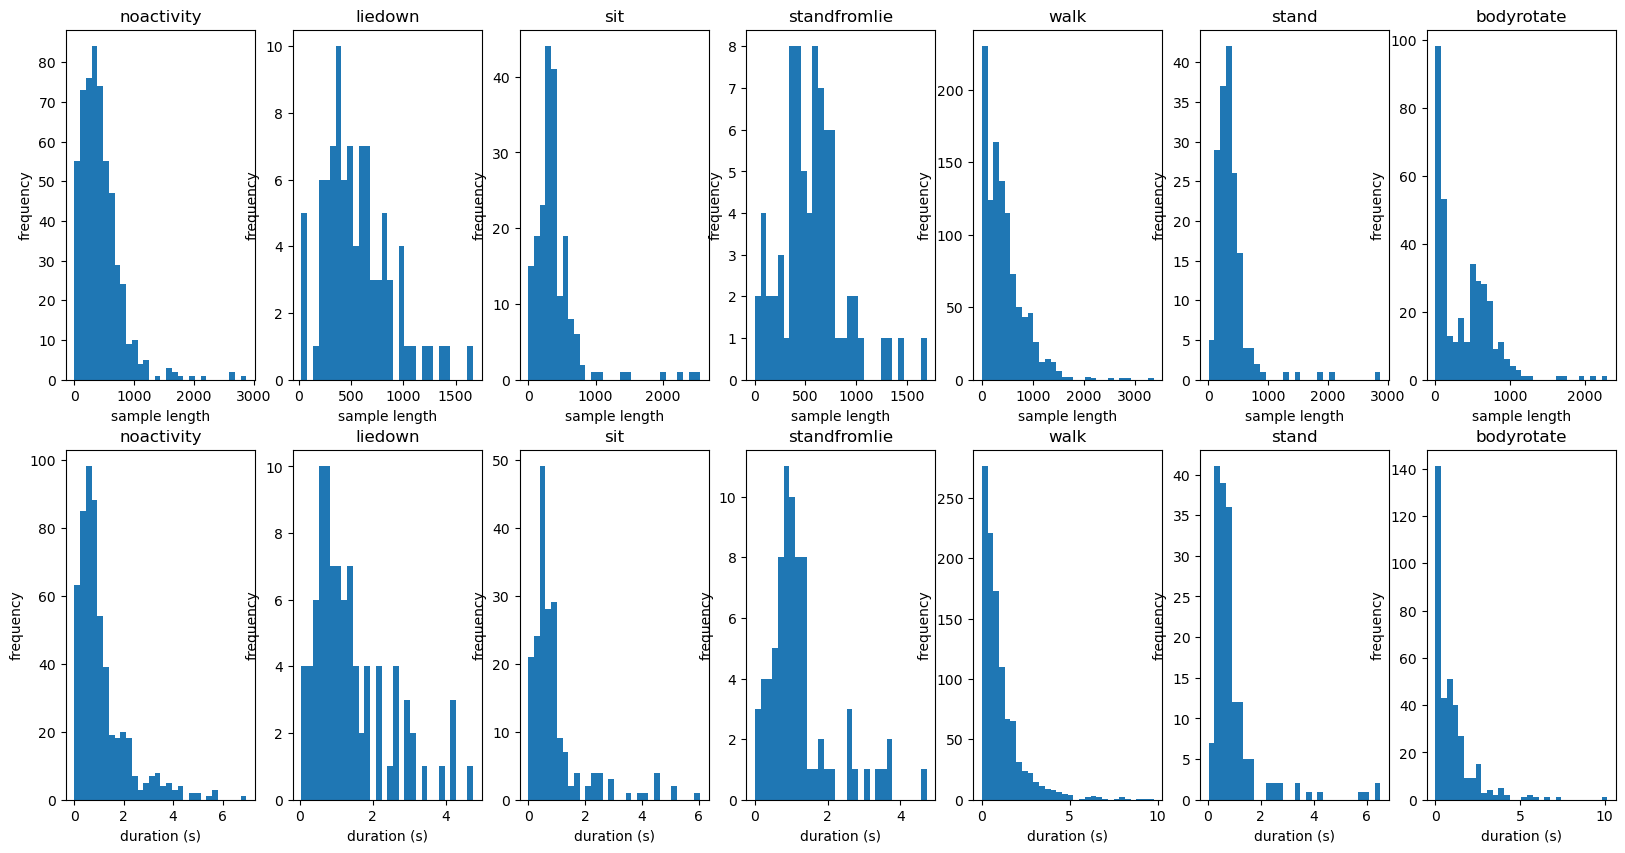

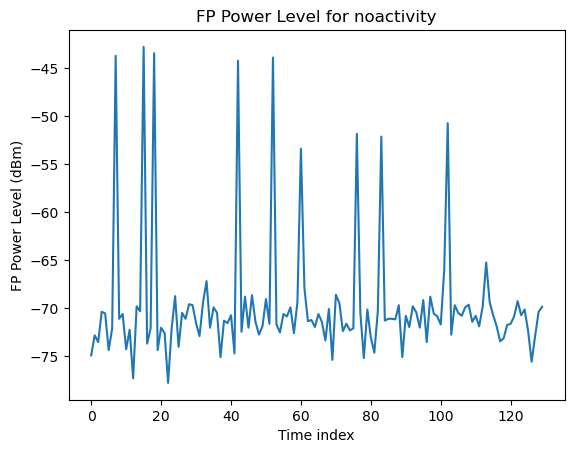

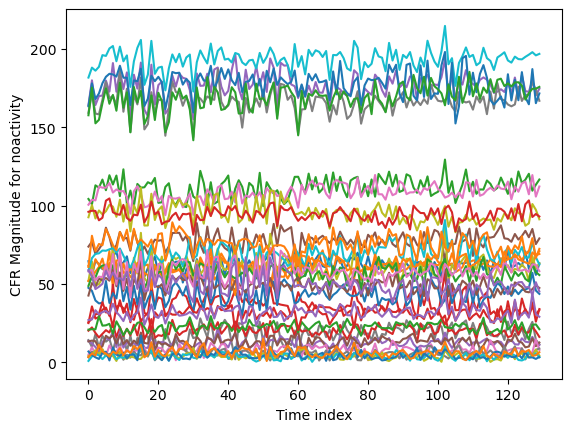

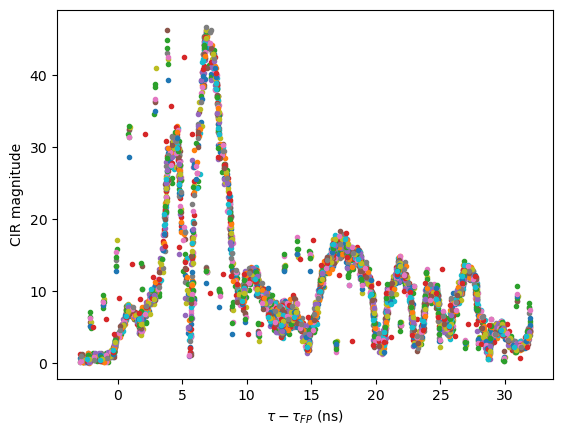

In [21]:
# load the pickle file
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('OPERAnet_UWB1_Activity_Recognition_Database.pkl', 'rb') as f:
    OPERAnet_UWB1_Activity_Recognition_Database = pickle.load(f)

print(OPERAnet_UWB1_Activity_Recognition_Database.keys())

sampele_lengths = [end - start for start, end in zip(OPERAnet_UWB1_Activity_Recognition_Database['act_start_index'], OPERAnet_UWB1_Activity_Recognition_Database['act_end_index'])]
sampele_lengths = np.array(sampele_lengths)

durations = [end - start for start, end in zip(OPERAnet_UWB1_Activity_Recognition_Database['act_start_timestamp'], OPERAnet_UWB1_Activity_Recognition_Database['act_end_timestamp'])]
durations = [d.total_seconds() for d in durations]

# print the set of unique activity labels
# print(set(OPERAnet_UWB1_Activity_Recognition_Database['activity']))
activity_list = OPERAnet_UWB1_Activity_Recognition_Database['activity']

num_act = len(set(activity_list))
fig, axs = plt.subplots(2, num_act, figsize=(20, 10))

for k, activity in enumerate(set(activity_list)):
    act_index = [i for i, act in enumerate(activity_list) if act == activity]
    act_lengths = sampele_lengths[act_index]
    act_durations = np.array(durations)[act_index]
    
    axs[0, k].hist(act_lengths, bins=30)
    axs[0, k].set_title(activity)
    axs[0, k].set_xlabel('sample length')
    axs[0, k].set_ylabel('frequency')
    
    axs[1, k].hist(act_durations, bins=30)
    axs[1, k].set_title(activity)
    axs[1, k].set_xlabel('duration (s)')
    axs[1, k].set_ylabel('frequency')
plt.show()


exp_id = OPERAnet_UWB1_Activity_Recognition_Database['exp_id']
person_id = OPERAnet_UWB1_Activity_Recognition_Database['person_id']
room_no = OPERAnet_UWB1_Activity_Recognition_Database['room_no']
activity = OPERAnet_UWB1_Activity_Recognition_Database['activity']
act_start_index = OPERAnet_UWB1_Activity_Recognition_Database['act_start_index']
act_end_index = OPERAnet_UWB1_Activity_Recognition_Database['act_end_index']
act_start_timestamp = OPERAnet_UWB1_Activity_Recognition_Database['act_start_timestamp']
act_end_timestamp = OPERAnet_UWB1_Activity_Recognition_Database['act_end_timestamp']
fp_pow_dbm = OPERAnet_UWB1_Activity_Recognition_Database['fp_pow_dbm']
fp_index = OPERAnet_UWB1_Activity_Recognition_Database['fp_index']
CIR = OPERAnet_UWB1_Activity_Recognition_Database['CIR']

select_sample_index = 0


plt.figure()
plt.plot(fp_pow_dbm[select_sample_index])
plt.xlabel('Time index')
plt.ylabel('FP Power Level (dBm)')
plt.title('FP Power Level' + ' for ' + activity[select_sample_index])
plt.show()


CFR = np.fft.fft(CIR[select_sample_index], axis=1)
plt.figure()
plt.plot((np.abs(CFR)))
plt.ylabel('CFR Magnitude' + ' for ' + activity[select_sample_index])
plt.xlabel('Time index')
plt.show()

# Plot aligned CIR measurements
len1 = 35
first_path_offset = -2
CIR_samp_period = 1 / (2 * (499.2e6))
SpeedofLight = 299792458
CIR_prop_time_axis1 = np.arange(first_path_offset, first_path_offset + (len1-0.5) * CIR_samp_period * 1e9, CIR_samp_period * 1e9)
# print(CIR_prop_time_axis1.shape)

fp_index_n = np.mod(np.abs(fp_index[select_sample_index]), 1)
time_Offset1 = fp_index_n * CIR_samp_period * 1e9
# print(time_Offset1.shape)
CIR_mag = np.abs(CIR[select_sample_index])
# print(CIR_mag.shape)

time_Offset1 = time_Offset1[:, np.newaxis].T
# print(time_Offset1.shape)
plt.figure()
plt.plot((CIR_prop_time_axis1[:, np.newaxis] - time_Offset1), (CIR_mag[:, :]).T, '.')
plt.xlabel(r'$\tau - \tau_{FP}$ (ns)')
plt.ylabel('CIR magnitude')
plt.show()



In [25]:
print(set(OPERAnet_UWB1_Activity_Recognition_Database['activity']))

print(CIR[100].shape)

{'noactivity', 'liedown', 'sit', 'standfromlie', 'walk', 'stand', 'bodyrotate'}
(244, 35)


###### UW2: Data segmentation and creat the database for activity recognition.

In [1]:
from tqdm import tqdm
import pandas as pd
import numpy as np  
import pickle

OPERAnet_UWB2_Activity_Recognition_Database = {
    'exp_id': [],
    'person_id': [],
    'room_no': [],
    'activity': [],
    'act_start_index': [],
    'act_end_index': [],
    'act_start_timestamp': [],
    'act_end_timestamp': [],
    'fp_pow_dbm': [],
    'fp_index': [],
    'CIR': [],
}

act_recognition_exp_indexes = [3,7, 11,15,21,25, 4,8,12,16,22,26, 5,9,13,17,23,27, 18,29,33, 56,57,58,59,60,61] 

for exp_id in act_recognition_exp_indexes:
    uwb_sys2_file = 'uwb2/' + 'uwb2_exp%03d.csv'%(exp_id)
    uwb_sys2_df = pd.read_csv(uwb_sys2_file)
    uwb_sys2_df['timestamp'] = pd.to_datetime(uwb_sys2_df['timestamp'], format='%H:%M:%S.%f')
    tx_id_uwb2 = uwb_sys2_df['tx_id']
    rx_id_uwb2 = uwb_sys2_df['rx_id']
    # Filter bidirectional data between nodes 3 and 4 (UWB2)
    idx_2 = uwb_sys2_df[(tx_id_uwb2 == 3) & (rx_id_uwb2 == 4) | (tx_id_uwb2 == 4) & (rx_id_uwb2 == 3)].index
    Filtered_data = uwb_sys2_df.loc[idx_2]
    # print(Filtered_data.head())
    # convert the CIR string to complex number
    Filtered_data.iloc[:, 29:79] = Filtered_data.iloc[:, 29:79].applymap(lambda x: complex(x.replace('i', 'j')))
    
    for i in tqdm(range(Filtered_data.shape[0])):
        if i == 0:
            start_time = Filtered_data['timestamp'].iloc[0]
            start_index = 0
            continue
        if Filtered_data['activity'].iloc[i] != Filtered_data['activity'].iloc[i-1]:
            # save the previous activity information
            OPERAnet_UWB2_Activity_Recognition_Database['exp_id'].append(exp_id)
            OPERAnet_UWB2_Activity_Recognition_Database['person_id'].append(uwb_sys2_df['person_id'][i-1])
            OPERAnet_UWB2_Activity_Recognition_Database['room_no'].append(uwb_sys2_df['room_no'][i-1])
            OPERAnet_UWB2_Activity_Recognition_Database['activity'].append(uwb_sys2_df['activity'][i-1])
            OPERAnet_UWB2_Activity_Recognition_Database['act_start_index'].append(start_index)
            OPERAnet_UWB2_Activity_Recognition_Database['act_end_index'].append(i)
            OPERAnet_UWB2_Activity_Recognition_Database['act_start_timestamp'].append(start_time)
            OPERAnet_UWB2_Activity_Recognition_Database['act_end_timestamp'].append(uwb_sys2_df['timestamp'][i-1])
            OPERAnet_UWB2_Activity_Recognition_Database['fp_pow_dbm'].append(np.array(Filtered_data['fp_pow_dbm'][start_index:i].values))
            OPERAnet_UWB2_Activity_Recognition_Database['fp_index'].append(np.array(Filtered_data['fp_index'][start_index:i].values))
            OPERAnet_UWB2_Activity_Recognition_Database['CIR'].append(np.array(Filtered_data.iloc[start_index:i, 29:79].values))
            start_time = uwb_sys2_df['timestamp'][i]
            start_index = i

print("The total number of activity recognition experiments: ", len(OPERAnet_UWB2_Activity_Recognition_Database['exp_id']))

with open('OPERAnet_UWB2_Activity_Recognition_Database.pkl', 'wb') as f:
    pickle.dump(OPERAnet_UWB2_Activity_Recognition_Database, f)
    


100%|██████████| 32510/32510 [00:00<00:00, 66113.62it/s]


The total number of activity recognition experiments:  2649


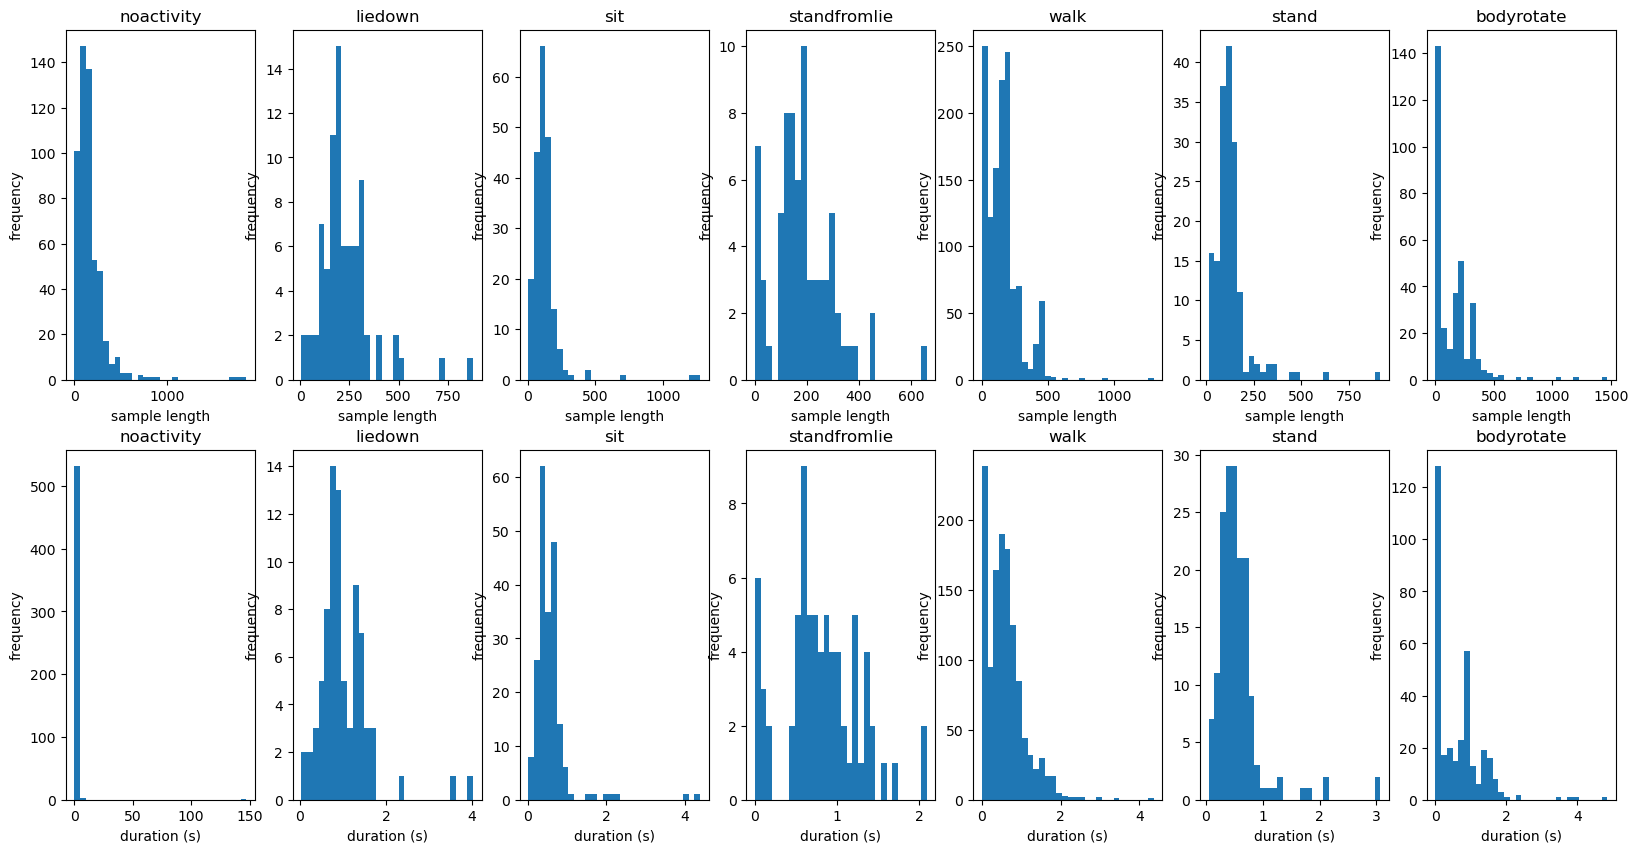

(45, 50)
AAA


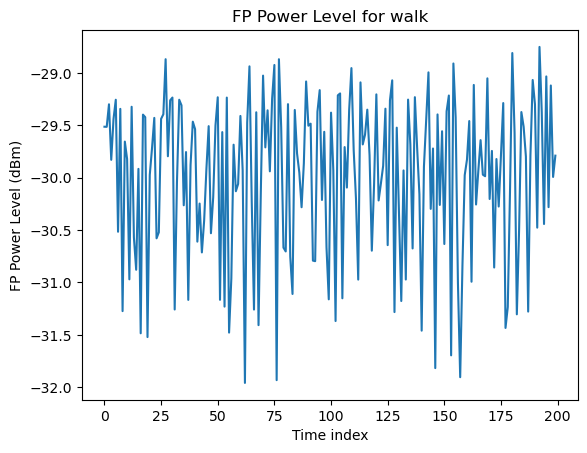

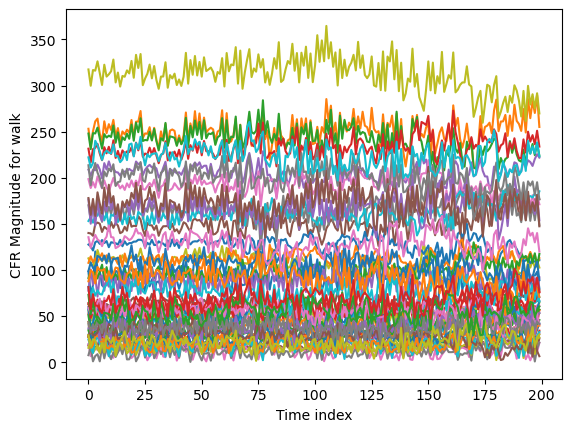

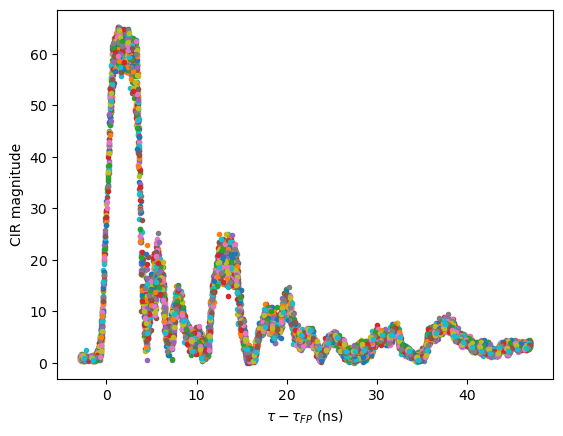

In [2]:
# load the pickle file
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('OPERAnet_UWB2_Activity_Recognition_Database.pkl', 'rb') as f:
    OPERAnet_UWB2_Activity_Recognition_Database = pickle.load(f)


sampele_lengths = [end - start for start, end in zip(OPERAnet_UWB2_Activity_Recognition_Database['act_start_index'], OPERAnet_UWB2_Activity_Recognition_Database['act_end_index'])]
sampele_lengths = np.array(sampele_lengths)

durations = [end - start for start, end in zip(OPERAnet_UWB2_Activity_Recognition_Database['act_start_timestamp'], OPERAnet_UWB2_Activity_Recognition_Database['act_end_timestamp'])]
durations = [d.total_seconds() for d in durations]

# print the set of unique activity labels
# print(set(OPERAnet_UWB2_Activity_Recognition_Database['activity']))
activity_list = OPERAnet_UWB2_Activity_Recognition_Database['activity']

num_act = len(set(activity_list))
fig, axs = plt.subplots(2, num_act, figsize=(20, 10))

for k, activity in enumerate(set(activity_list)):
    act_index = [i for i, act in enumerate(activity_list) if act == activity]
    act_lengths = sampele_lengths[act_index]
    act_durations = np.array(durations)[act_index]
    
    axs[0, k].hist(act_lengths, bins=30)
    axs[0, k].set_title(activity)
    axs[0, k].set_xlabel('sample length')
    axs[0, k].set_ylabel('frequency')
    
    axs[1, k].hist(act_durations, bins=30)
    axs[1, k].set_title(activity)
    axs[1, k].set_xlabel('duration (s)')
    axs[1, k].set_ylabel('frequency')
plt.show()


exp_id = OPERAnet_UWB2_Activity_Recognition_Database['exp_id']
person_id = OPERAnet_UWB2_Activity_Recognition_Database['person_id']
room_no = OPERAnet_UWB2_Activity_Recognition_Database['room_no']
activity = OPERAnet_UWB2_Activity_Recognition_Database['activity']
act_start_index = OPERAnet_UWB2_Activity_Recognition_Database['act_start_index']
act_end_index = OPERAnet_UWB2_Activity_Recognition_Database['act_end_index']
act_start_timestamp = OPERAnet_UWB2_Activity_Recognition_Database['act_start_timestamp']
act_end_timestamp = OPERAnet_UWB2_Activity_Recognition_Database['act_end_timestamp']
fp_pow_dbm = OPERAnet_UWB2_Activity_Recognition_Database['fp_pow_dbm']
fp_index = OPERAnet_UWB2_Activity_Recognition_Database['fp_index']
CIR = OPERAnet_UWB2_Activity_Recognition_Database['CIR']

print(CIR[0].shape)

print("AAA")

select_sample_index = 1000


plt.figure()
plt.plot(fp_pow_dbm[select_sample_index])
plt.xlabel('Time index')
plt.ylabel('FP Power Level (dBm)')
plt.title('FP Power Level' + ' for ' + activity[select_sample_index])
plt.show()


CFR = np.fft.fft(CIR[select_sample_index], axis=1)
plt.figure()
plt.plot((np.abs(CFR)))
plt.ylabel('CFR Magnitude' + ' for ' + activity[select_sample_index])
plt.xlabel('Time index')
plt.show()

# Plot aligned CIR measurements

len2 = 50
first_path_offset = -2
CIR_samp_period = 1 / (2 * (499.2e6))
SpeedofLight = 299792458
CIR_prop_time_axis2 = np.arange(first_path_offset, first_path_offset + (len2-0.5) * CIR_samp_period * 1e9, CIR_samp_period * 1e9)

fp_index_n = np.mod(np.abs(fp_index[select_sample_index]), 1)
time_Offset2 = fp_index_n * CIR_samp_period * 1e9
CIR_mag = np.abs(CIR[select_sample_index])

time_Offset2 = time_Offset2[:, np.newaxis].T

plt.figure()
plt.plot((CIR_prop_time_axis2[:, np.newaxis] - time_Offset2), (CIR_mag[:, :]).T, '.')
plt.xlabel(r'$\tau - \tau_{FP}$ (ns)')
plt.ylabel('CIR magnitude')
plt.show()


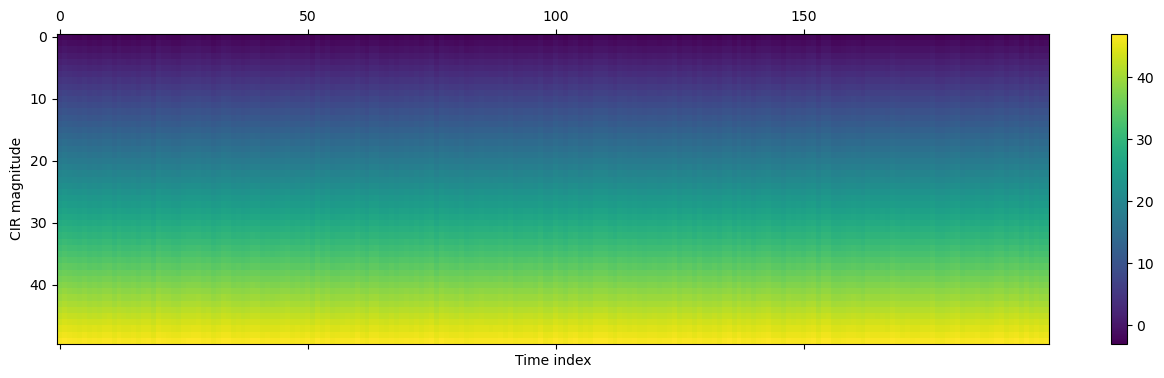

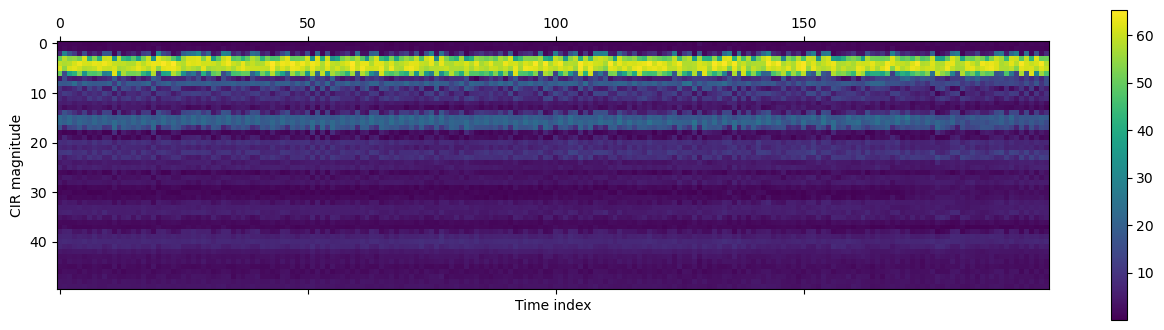

In [20]:
x_axis = CIR_prop_time_axis2[:, np.newaxis] - time_Offset2

plt.matshow(x_axis, aspect='auto')
plt.xlabel('Time index')
plt.colorbar()
plt.ylabel('CIR magnitude')
plt.show()



map_n = CIR_mag[:, :].T
mmm = np.array(map_n, dtype=float)
plt.matshow(mmm)
plt.xlabel('Time index')
plt.ylabel('CIR magnitude')
plt.colorbar()
plt.show()

#### UWB Crowd Counting Data

In [ ]:
# task_experiment_index_map  = {
#     'Background': [1,19,55],                     # [1,19] room 1, [55] room 2
#     'sitting': [3,7,11,15,21,25],                # Room 1
#     'standing_from_chair': [3,7,11,15,21,25],    # Room 1
#     'lying': [4,8,12,16,22,26],                  # Room 1
#     'standing_from_floor': [4,8,12,16,22,26],    # Room 1
#     'body_rotating': [5,9,13,17,23,27],          # Room 1
#     'random_motion': [18,29,33],                 # Room 1
#     'orderly_motion': [56,57,58,59,60,61],       # Room 2
#     'crowd_counting':[28],                       # Room 1;;  exp028 is **the crowd counting** experiment whereby six people walked randomly 
#                                                             # and continuously within the monitoring area of Room 1.
#                                                             # Then, after approximately every 5 minutes, one person moved out of the room.
# }

# # for the crowd counting experiment (exp028), 
# person_ids = ['All Six People']
# room_nos = [1]
# activities = [
#     'noactivity',
#     '6_persons_tag_leftarm',
#     '5_persons_tag_leftarm',
#     '4_persons_tag_leftarm',
#     '3_persons_tag_leftarm',
#     '2_persons_tag_leftarm',
#     '1_persons_tag_leftarm',
#     ]

#### UWB data processing method from OPERAnet

The FP (First Path) Power Level in a UWB (Ultra-Wideband) system refers to the power of the first arriving signal path, which is typically the direct line-of-sight signal. This metric is crucial in UWB systems as it helps in accurate ranging and positioning by identifying the first signal that arrives at the receiver. The FP Power Level is usually measured in dBm (decibels relative to one milliwatt) and can be influenced by factors such as distance, obstacles, and the environment in which the UWB system operates.

In practice, the FP Power Level is used to determine the strength and quality of the received signal, which in turn affects the precision of ranging and localization applications. Higher FP Power Levels generally indicate a clearer and stronger signal, leading to more accurate distance measurements.

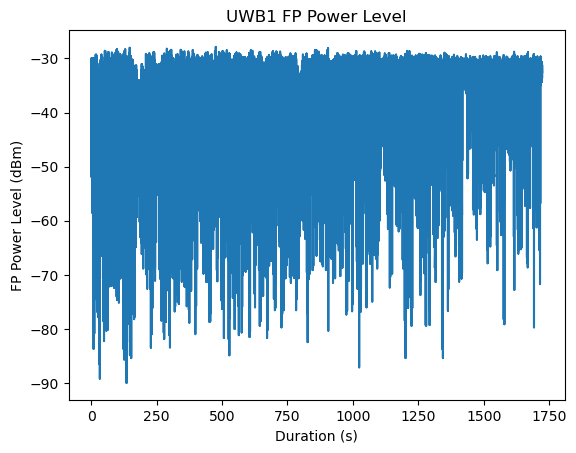

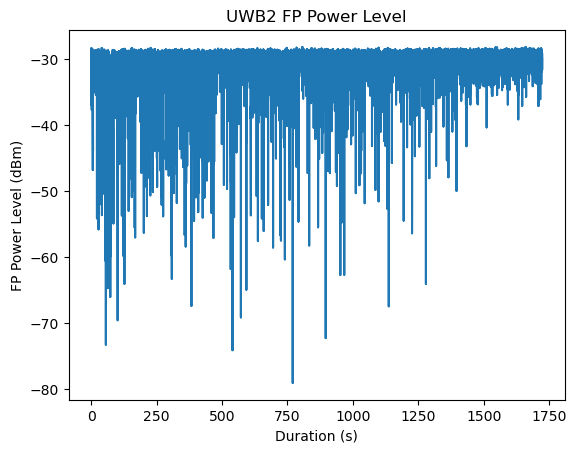

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load data from CSV files
uwb1 = pd.read_csv('uwb1/uwb1_exp028.csv')
uwb2 = pd.read_csv('uwb2/uwb2_exp028.csv')

# Convert timestamps to datetime objects
uwb1['timestamp'] = pd.to_datetime(uwb1['timestamp'], format='%H:%M:%S.%f')
uwb2['timestamp'] = pd.to_datetime(uwb2['timestamp'], format='%H:%M:%S.%f')

tx_id_uwb1 = uwb1['tx_id']
rx_id_uwb1 = uwb1['rx_id']
tx_id_uwb2 = uwb2['tx_id']
rx_id_uwb2 = uwb2['rx_id']

# Filter bidirectional data between nodes 0 and 3 (UWB1)
idx_1 = uwb1[(tx_id_uwb1 == 0) & (rx_id_uwb1 == 3) | (tx_id_uwb1 == 3) & (rx_id_uwb1 == 0)].index
Filtered_data1 = uwb1.loc[idx_1]

# Filter bidirectional data between nodes 3 and 4 (UWB2)
idx_2 = uwb2[(tx_id_uwb2 == 3) & (rx_id_uwb2 == 4) | (tx_id_uwb2 == 4) & (rx_id_uwb2 == 3)].index
Filtered_data2 = uwb2.loc[idx_2]

# Calculate time durations for UWB1
t_uwb1 = Filtered_data1['timestamp']
out = np.diff(t_uwb1.values.astype('datetime64[s]').astype(np.int64))
actualtime1 = np.insert(out, 0, 0)
time_duration = np.cumsum(actualtime1)

# Calculate time durations for UWB2
t_uwb2 = Filtered_data2['timestamp']
out2 = np.diff(t_uwb2.values.astype('datetime64[s]').astype(np.int64))
actualtime2 = np.insert(out2, 0, 0)
time_duration2 = np.cumsum(actualtime2)

# Plot FP Power Level (dBm) for UWB1
plt.figure()
plt.plot(time_duration, Filtered_data1['fp_pow_dbm'])
plt.xlabel('Duration (s)')
plt.ylabel('FP Power Level (dBm)')
plt.title('UWB1 FP Power Level')
plt.show()

# Plot FP Power Level (dBm) for UWB2
plt.figure()
plt.plot(time_duration2, Filtered_data2['fp_pow_dbm'])
plt.xlabel('Duration (s)')
plt.ylabel('FP Power Level (dBm)')
plt.title('UWB2 FP Power Level')
plt.show()


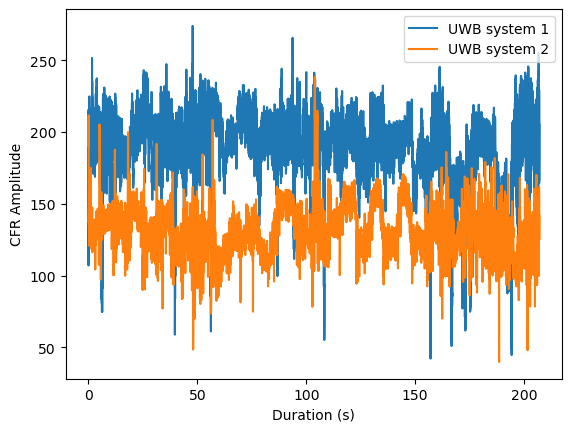

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.fftpack import fft

# Load data from CSV files
uwb1 = pd.read_csv('uwb1/uwb1_exp018.csv')
uwb2 = pd.read_csv('uwb2/uwb2_exp018.csv')

# Extract necessary columns
tx_id_uwb1 = uwb1['tx_id']
rx_id_uwb1 = uwb1['rx_id']
tx_id_uwb2 = uwb2['tx_id']
rx_id_uwb2 = uwb2['rx_id']

# find bidirectional data between nodes 0 and 3 (UWB1)
idx_1 = uwb1[(tx_id_uwb1 == 0) & (rx_id_uwb1 == 3) | (tx_id_uwb1 == 3) & (rx_id_uwb1 == 0)].index
Filtered_data1 = uwb1.loc[idx_1]

# find bidirectional data between nodes 1 and 2 (UWB2)
idx_2 = uwb2[(tx_id_uwb2 == 1) & (rx_id_uwb2 == 2) | (tx_id_uwb2 == 2) & (rx_id_uwb2 == 1)].index
Filtered_data2 = uwb2.loc[idx_2]

# Convert timestamps to datetime objects
date1 = pd.to_datetime(Filtered_data1['timestamp'], format='%H:%M:%S.%f')
date2 = pd.to_datetime(Filtered_data2['timestamp'], format='%H:%M:%S.%f')

# Convert CIR data to CFR using FFT
Filtered_data1.iloc[:, 29:64] = Filtered_data1.iloc[:, 29:64].applymap(lambda x: complex(x.replace('i', 'j')))
Filtered_data2.iloc[:, 29:79] = Filtered_data2.iloc[:, 29:79].applymap(lambda x: complex(x.replace('i', 'j')))
# print(Filtered_data1.iloc[:, 29:64].values)
# print(Filtered_data1.iloc[:, 29:64].values.shape)                                      
# CFR_1 = fft(Filtered_data1.iloc[:, 29:64].values, axis=1)
# CFR_2 = fft(Filtered_data2.iloc[:, 29:79].values, axis=1)

CFR_1 = np.fft.fft(Filtered_data1.iloc[:, 29:64].values, axis=1) # convert 35 samples of CIR data into CFR (UWB system 1)
CFR_2 = np.fft.fft(Filtered_data2.iloc[:, 29:79].values, axis=1) # convert 50 samples of CIR data into CFR (UWB system 2)

# plot for a given duration
start_time = datetime.strptime('18:04:44.553', '%H:%M:%S.%f')
end_time = datetime.strptime('18:08:11.553', '%H:%M:%S.%f')

# Find indices for the start and end times
idx1 = np.argmin([abs((start_time - t).total_seconds()) for t in date1])
idx11 = np.argmin([abs((end_time - t).total_seconds()) for t in date1])
idx2 = np.argmin([abs((start_time - t).total_seconds()) for t in date2])
idx22 = np.argmin([abs((end_time - t).total_seconds()) for t in date2])

# Calculate time durations
t_uwb1 = date1[idx1:idx11+1]
out = np.diff([t.timestamp() for t in t_uwb1])
actualtime1 = np.insert(out, 0, 0)
time_duration = np.cumsum(actualtime1)

t_uwb2 = date2[idx2:idx22+1]
out2 = np.diff([t.timestamp() for t in t_uwb2])
actualtime2 = np.insert(out2, 0, 0)
time_duration2 = np.cumsum(actualtime2)

# Plot raw un-filtered data
plt.figure()
plt.plot(time_duration, np.abs(CFR_1[idx1:idx11+1, 9]), label='UWB system 1')
plt.plot(time_duration2, np.abs(CFR_2[idx2:idx22+1, 9]), label='UWB system 2')
plt.legend()
plt.xlabel('Duration (s)')
plt.ylabel('CFR Amplitude')
plt.show()


(63944,)
(1, 1000)


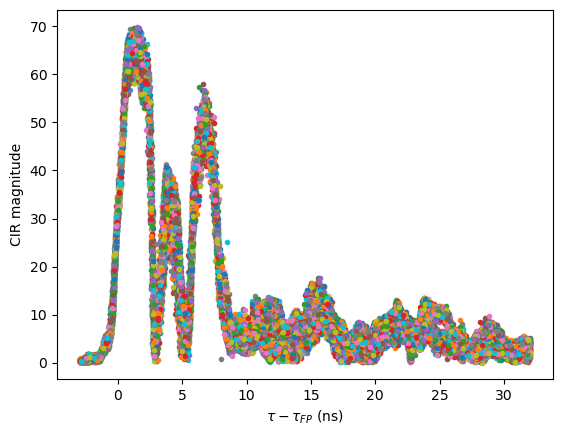

(50, 1)
(1, 1000)


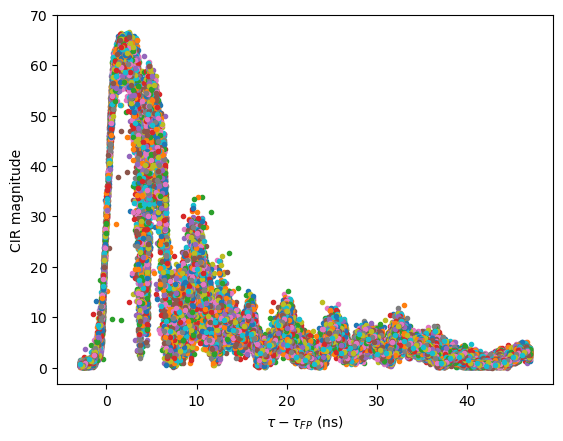

In [39]:
# Plot aligned CIR measurements
len1 = 35
len2 = 50
first_path_offset = -2
CIR_samp_period = 1 / (2 * (499.2e6))
SpeedofLight = 299792458
CIR_prop_time_axis1 = np.arange(first_path_offset, first_path_offset + (len1-0.5) * CIR_samp_period * 1e9, CIR_samp_period * 1e9)
CIR_prop_time_axis2 = np.arange(first_path_offset, first_path_offset + (len2-0.5) * CIR_samp_period * 1e9, CIR_samp_period * 1e9)

CIR1 = Filtered_data1.iloc[:, -len1:].values
CIR2 = Filtered_data2.iloc[:, -len2:].values
FP_idx1 = Filtered_data1['fp_index'].to_numpy()
FP_idx2 = Filtered_data2['fp_index'].to_numpy()
fp1 = np.mod(np.abs(FP_idx1), 1)
fp2 = np.mod(np.abs(FP_idx2), 1)
time_Offset1 = fp1 * CIR_samp_period * 1e9
time_tOffset2 = fp2 * CIR_samp_period * 1e9
CIR_mag1 = np.abs(CIR1)
CIR_mag2 = np.abs(CIR2)



# Plot bidirectional CIR data between a given pair of nodes
start_idx = 0
end_idx = 1000

print(FP_idx1.shape)
# print((CIR_prop_time_axis1 - time_Offset1[start_idx:end_idx]).T)
time_1 = time_Offset1[start_idx:end_idx]
# shape (1000,) -> (1000, 1)
time_1 = time_1[:, np.newaxis]
print(time_1.T.shape)
time_2 = time_tOffset2[start_idx:end_idx]
time_2 = time_2[:, np.newaxis]
plt.figure()
plt.plot((CIR_prop_time_axis1[:, np.newaxis] - time_1.T), (CIR_mag1[start_idx:end_idx, :]).T, '.')
plt.xlabel(r'$\tau - \tau_{FP}$ (ns)')
plt.ylabel('CIR magnitude')
plt.show()
print(CIR_prop_time_axis2[:, np.newaxis].shape)
print(time_2.T.shape)
plt.figure()
plt.plot((CIR_prop_time_axis2[:, np.newaxis] - time_2.T), (CIR_mag2[start_idx:end_idx, :]).T, '.')
plt.xlabel(r'$\tau - \tau_{FP}$ (ns)')
plt.ylabel('CIR magnitude')
plt.show()

### Processing the WiFi CSI data

Since the save csi data is in the .mat matlab format and the data stored in tables, we need to use the following matlab code to convert the data to the format that can be load in python.

#### Loading the data to python

In [3]:
exp_id = 28

In [ ]:
from datetime import datetime, timedelta
import pywt
import mat73
import pandas as pd
import scipy.io as sio
exp_id = 28
annotations = pd.read_csv('wificsi1-csv/wificsi1_exp%03d.tsv'%(exp_id), sep='\t')

try:
    data = sio.loadmat('wificsi1-py/wificsi1_exp%03d.mat'%(exp_id))
except:
    data = mat73.loadmat('wificsi1-py/wificsi1_exp%03d.mat'%(exp_id))

print(annotations.head(2))
print(data['csi'].shape)
print(data['header'])
print(len(data['timestamp']))

In [1]:
from datetime import datetime, timedelta
import pywt
import mat73
import pandas as pd
import scipy.io as sio
data = mat73.loadmat('wificsi1/wificsi1_exp001.mat')
print(data)


ERROR:root:ERROR: MATLAB type not supported: table, (uint32)


{'wifi_csi_1': None}


In [2]:
import h5py

# 使用 h5py 打开文件
with h5py.File('wificsi1/wificsi1_exp001.mat', 'r') as file:
    # 查看文件中的所有数据集
    print(list(file.keys()))

    print(file['#refs#'].keys())
    # 访问 wifi_csi_1 数据
    wifi_csi_1 = file['wifi_csi_1'][:]  # 加载数据
    print(type(wifi_csi_1))  # 打印数据类型
    print(wifi_csi_1.shape)
    print(wifi_csi_1)

['#refs#', '#subsystem#', 'wifi_csi_1']
<KeysViewHDF5 ['#a', '#b', '#c', '#d', '#e', '#f', '#g', '#h', '#i', '#j', '#k', '#l', '0', '00', '00b', '00c', '00d', '00e', '00f', '00g', '00h', '00i', '00j', '00k', '00l', '00m', '00n', '00o', '00p', '00q', '00r', '00s', '00t', '00u', '00v', '00w', '00x', '00y', '00z', '01', '01b', '01c', '01d', '01e', '01f', '01g', '01h', '01i', '01j', '01k', '01l', '01m', '01n', '01o', '01p', '01q', '01r', '01s', '01t', '01u', '01v', '01w', '01x', '01y', '01z', '02', '02b', '02c', '02d', '02e', '02f', '02g', '02h', '02i', '02j', '02k', '02l', '02m', '02n', '02o', '02p', '02q', '02r', '02s', '02t', '02u', '02v', '02w', '02x', '02y', '02z', '03', '03b', '03c', '03d', '03e', '03f', '03g', '03h', '03i', '03j', '03k', '03l', '03m', '03n', '03o', '03p', '03q', '03r', '03s', '03t', '03u', '03v', '03w', '03x', '03y', '03z', '04', '04b', '04c', '04d', '04e', '04f', '04g', '04h', '04i', '04j', '04k', '04l', '04m', '04n', '04o', '04p', '04q', '04r', '04s', '04t', '04u'

In [3]:
import hdf5storage

# Load the .mat file
data = hdf5storage.loadmat('wificsi1/wificsi1_exp001.mat')
wifi_csi_1 = data['wifi_csi_1']
print("wifi_csi_1:", wifi_csi_1)


ModuleNotFoundError: No module named 'hdf5storage'

In [10]:
import pandas as pd

# 读取 TSV 文件
file_path = 'wificsi1-csv/wificsi1_exp001.tsv'  # 替换为你的文件路径
df = pd.read_csv(file_path, sep='\t')

# 打印数据的前几行
print("数据的前几行:")
print(df.head())

# 打印数据的基本信息
print("\n数据的基本信息:")
print(df.info())

数据的前几行:
   14:35:38.497|background|exp_001|nan|1|
0  14:35:38.497|background|exp_001|nan|1|
1  14:35:38.498|background|exp_001|nan|1|
2  14:35:38.499|background|exp_001|nan|1|
3  14:35:38.499|background|exp_001|nan|1|
4  14:35:38.500|background|exp_001|nan|1|

数据的基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625561 entries, 0 to 625560
Data columns (total 1 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   14:35:38.497|background|exp_001|nan|1|  625561 non-null  object
dtypes: object(1)
memory usage: 4.8+ MB
None


In [19]:
from datetime import datetime
print(df.iloc[0,0][:12])
print(type(df.iloc[0,0]))
print(df.shape)
t1 = df.iloc[0,0][:12]
t2 = df.iloc[-1,0][:12]
time_obj1 = datetime.strptime(t1, "%H:%M:%S.%f")
time_obj2 = datetime.strptime(t2, "%H:%M:%S.%f")
# 计算时间差
time_diff = time_obj2 - time_obj1
seconds_diff = time_diff.total_seconds()

# 打印结果
print("时间1:", t1)
print("时间2:", t2)
print("时间1 - 时间2 的时间差为:", time_diff)
print("时间1 - 时间2 的时间差为 {:.3f} 秒".format(seconds_diff))

14:35:38.497
<class 'str'>
(625561, 1)
时间1: 14:35:38.497
时间2: 14:42:09.688
时间1 - 时间2 的时间差为: 0:06:31.191000
时间1 - 时间2 的时间差为 391.191 秒
